In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datasets import load_dataset
# Load the dataset
dataset = load_dataset("lukebarousse/data_jobs")
df = dataset["train"].to_pandas()

# Data Cleaning
df["job_posted_date"]=pd.to_datetime(df["job_posted_date"])

In [23]:
df.groupby("job_title_short").size()

job_title_short
Business Analyst              49063
Cloud Engineer                12331
Data Analyst                 196075
Data Engineer                186241
Data Scientist               172286
Machine Learning Engineer     14080
Senior Data Analyst           29216
Senior Data Engineer          44563
Senior Data Scientist         36957
Software Engineer             44929
dtype: int64

In [24]:
df.groupby('job_title_short').value_counts()

Series([], Name: count, dtype: int64)

In [25]:
df['job_title_short'].value_counts()

job_title_short
Data Analyst                 196075
Data Engineer                186241
Data Scientist               172286
Business Analyst              49063
Software Engineer             44929
Senior Data Engineer          44563
Senior Data Scientist         36957
Senior Data Analyst           29216
Machine Learning Engineer     14080
Cloud Engineer                12331
Name: count, dtype: int64

In [26]:
df.groupby('job_title_short')['job_title_short'].value_counts()

job_title_short
Business Analyst              49063
Cloud Engineer                12331
Data Analyst                 196075
Data Engineer                186241
Data Scientist               172286
Machine Learning Engineer     14080
Senior Data Analyst           29216
Senior Data Engineer          44563
Senior Data Scientist         36957
Software Engineer             44929
Name: count, dtype: int64

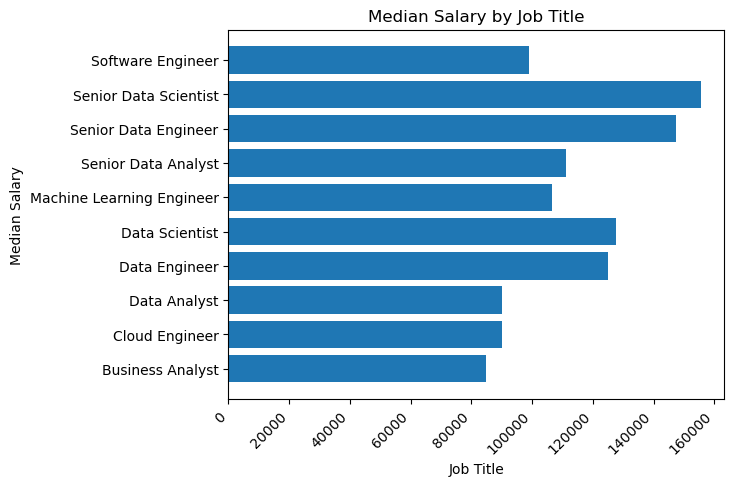

In [27]:
median_salary = df.groupby('job_title_short')['salary_year_avg'].median()

plt.barh(y=median_salary.index, width=median_salary.values)

plt.xlabel('Job Title')
plt.ylabel('Median Salary')
plt.title('Median Salary by Job Title')
plt.xticks(rotation=45, ha='right')
plt.show()

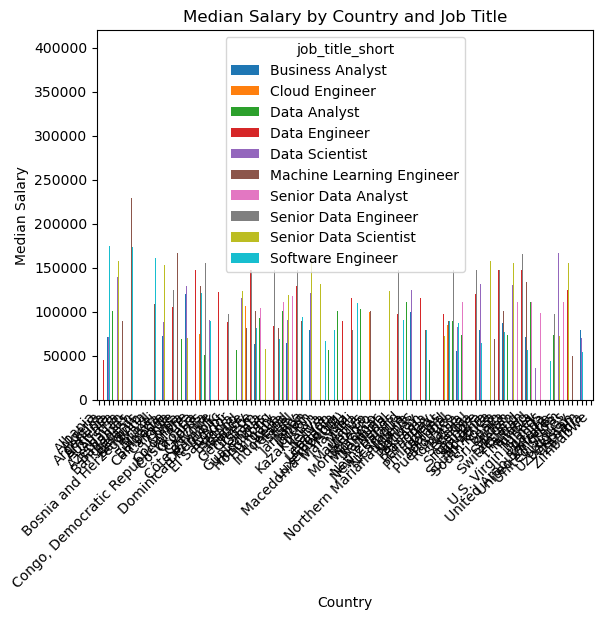

In [28]:
pivot_table = df.pivot_table(
    values='salary_year_avg',
    index='job_country',
    columns='job_title_short',
    aggfunc='median'
)
pivot_table.plot(kind='bar')

plt.xlabel('Country')
plt.ylabel('Median Salary')
plt.title('Median Salary by Country and Job Title')
plt.xticks(rotation=45, ha='right')
plt.show()

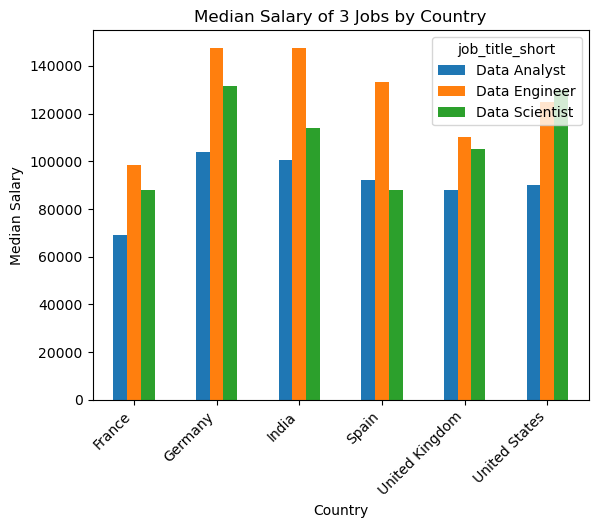

In [32]:
jobs = ['Data Analyst', 'Data Engineer', 'Data Scientist']

df_filtered = df[df['job_title_short'].isin(jobs)]

top_countries = df_filtered['job_country'].value_counts().head(6)

df_top_countries = df_filtered[df_filtered['job_country'].isin(top_countries.index)]

pivot_table_top = df_top_countries.pivot_table(
    values='salary_year_avg',
    index='job_country',
    columns='job_title_short',
    aggfunc='median'
)


pivot_table_top.head(6).plot(kind='bar')

plt.xlabel('Country')
plt.ylabel('Median Salary')
plt.title('Median Salary of 3 Jobs by Country')
plt.xticks(rotation=45, ha='right')
plt.show()

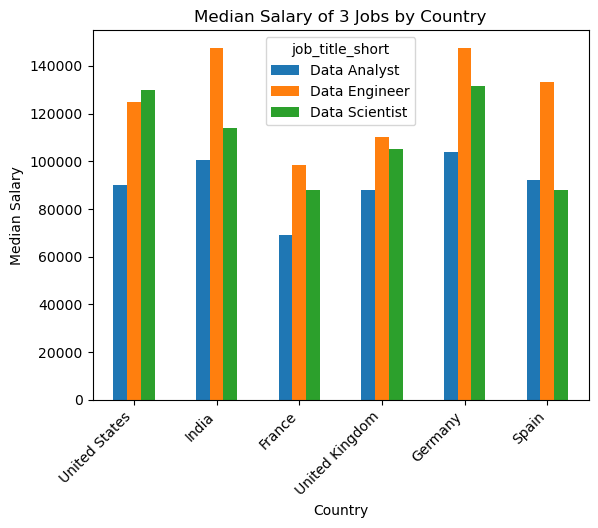

In [42]:
new_method=pivot_table.loc[top_countries.index]
df_filtered_2 = new_method.loc[:, jobs]

df_filtered_2.plot(kind='bar')

plt.xlabel('Country')
plt.ylabel('Median Salary')
plt.title('Median Salary of 3 Jobs by Country')
plt.xticks(rotation=45, ha='right')
plt.show()



job_title_short,Data Analyst,Data Engineer,Data Scientist
job_country,,,
United States,90000.0,125000.0,130000.0
India,100500.0,147500.0,114008.0
France,69175.0,98301.5,88128.0
United Kingdom,87750.0,110000.0,105300.0
Germany,103750.0,147500.0,131560.0
Spain,91977.0,133000.0,88128.0
